In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Lifelines is a survival analysis package
from lifelines import CoxPHFitter

import os, sys

root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

import warnings
warnings.filterwarnings("ignore")

from preprocessing import data_preprocessing

/home/glory/anaconda3/envs/churn_pred/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
path = root_dir + "/data/WA_Fn-UseC_-Telco-Customer-Churn.csv"

data = data_preprocessing(path)

data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


## Survival Regression Ananlysis using Cox Proportional Hazard model

In [3]:
cph_model = CoxPHFitter()
cph_model.fit(data, duration_col="tenure", event_col="Churn")

cph_model.print_summary()

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn'
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -12659.69
         time fit was run = 2025-09-26 14:24:51 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
gender                                 0.04      1.04      0.05           -0.05            0.13                0.95                1.14
SeniorCitizen                          0.03      1.04      0.06           -0.08            0.15                0.93                1.16
Partner                               -0.18      0.84      0.06           -0.29           -0.07                0.75                0.93
Dependents                            -0.09      0.91      0.07           -0.23            0.05                0.80                1.05
PhoneService                           0.83      2.29      0.47           -0.10            1.76                0.90                5.80
MultipleLines                          0.09      1.09      0.13           -0.16            0.33                0.85                1.40
OnlineSecurity                        -0.21      0.81      0.13           -0.47            0.05                0.62                1.05
OnlineBackup                          -0.06      0.95      0.13           -0.31            0.19                0.74                1.21
DeviceProtection                       0.09      1.09      0.13           -0.16            0.34                0.85                1.40
TechSupport                           -0.08      0.92      0.13           -0.34            0.17                0.71                1.19
StreamingTV                            0.28      1.32      0.24           -0.18            0.74                0.83                2.10
StreamingMovies                        0.29      1.33      0.24           -0.18            0.75                0.84                2.11
PaperlessBilling                       0.15      1.16      0.06            0.04            0.26                1.04                1.30
MonthlyCharges                         0.01      1.01      0.02           -0.03            0.06                0.97                1.06
TotalCharges                          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
InternetService_Fiber optic            1.02      2.77      0.58           -0.12            2.15                0.89                8.59
InternetService_No                    -2.34      0.10      0.60           -3.51           -1.17                0.03                0.31
Contract_One year                     -1.27      0.28      0.10           -1.46           -1.07                0.23                0.34
Contract_Two year                     -3.70      0.02      0.20           -4.10           -3.31                0.02                0.04
PaymentMethod_Credit card (automatic) -0.01      0.99      0.09           -0.19            0.17                0.83                1.18
PaymentMethod_Electronic check         0.39      1.47      0.07            0.24            0.53                1.28                1.70
PaymentMethod_Mailed check             0.51      1.67      0.09            0.34            0.68                1.40                1.98

                                       cmp to      z      p  -log2(p)
covariate                                                            
gender                                   0.00   0.85   0.40      1.33
SeniorCitizen                            0.00   0.61   0.54      0.88
Partner                                  0.00  -3.23 <0.005      9.67
Dependents          

In [4]:
test_id = data.sample(1)

test_id

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2872,1,0,1,1,42,1,1,0,0,0,...,22.95,1014.25,0,False,True,False,True,False,True,False


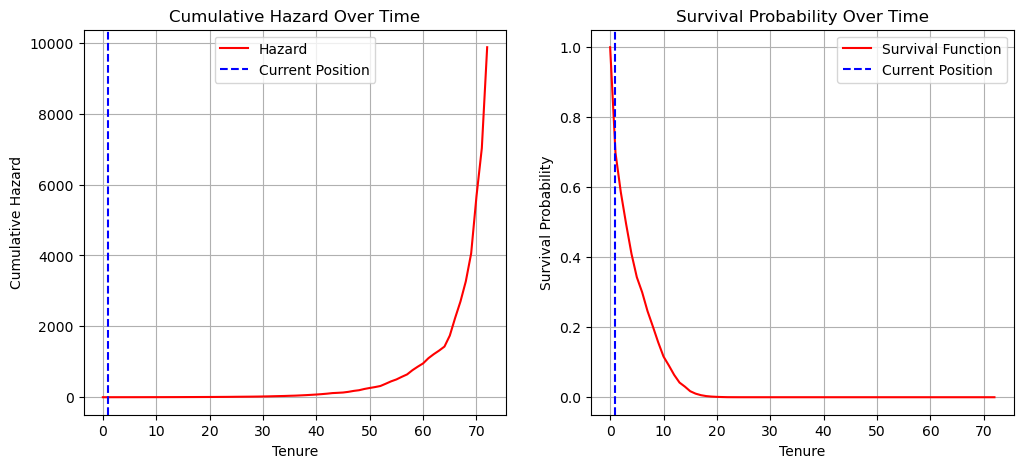

In [5]:
test_id = data.sample(1)
fig, ax = plt.subplots(1, 2, figsize=(12,5))

cph_model.predict_cumulative_hazard(test_id).plot(ax = ax[0], color = 'red')
ax[0].axvline(x=test_id.tenure.values[0], color = 'blue', linestyle='--')
ax[0].legend(labels=['Hazard','Current Position'])
ax[0].set_xlabel('Tenure', size = 10)
ax[0].set_ylabel('Cumulative Hazard', size = 10)
ax[0].set_title('Cumulative Hazard Over Time')
ax[0].grid()

cph_model.predict_survival_function(test_id).plot(ax = ax[1], color = 'red')
ax[1].axvline(x=test_id.tenure.values[0], color = 'blue', linestyle='--')
ax[1].legend(labels=['Survival Function','Current Position'])
ax[1].set_xlabel('Tenure', size = 10)
ax[1].set_ylabel('Survival Probability', size = 10)
ax[1].set_title('Survival Probability Over Time')
ax[1].grid()

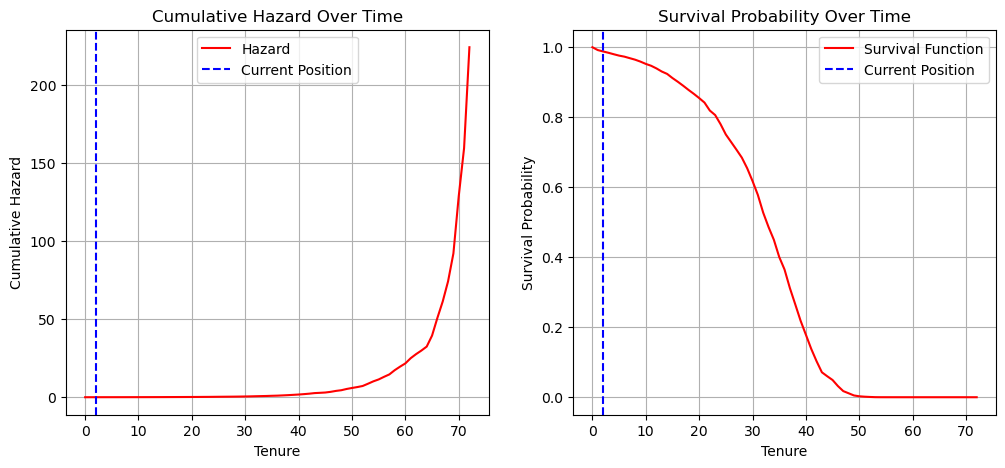

In [6]:
test_id = data.sample(1)
fig, ax = plt.subplots(1, 2, figsize=(12,5))

cph_model.predict_cumulative_hazard(test_id).plot(ax = ax[0], color = 'red')
ax[0].axvline(x=test_id.tenure.values[0], color = 'blue', linestyle='--')
ax[0].legend(labels=['Hazard','Current Position'])
ax[0].set_xlabel('Tenure', size = 10)
ax[0].set_ylabel('Cumulative Hazard', size = 10)
ax[0].set_title('Cumulative Hazard Over Time')
ax[0].grid()

cph_model.predict_survival_function(test_id).plot(ax = ax[1], color = 'red')
ax[1].axvline(x=test_id.tenure.values[0], color = 'blue', linestyle='--')
ax[1].legend(labels=['Survival Function','Current Position'])
ax[1].set_xlabel('Tenure', size = 10)
ax[1].set_ylabel('Survival Probability', size = 10)
ax[1].set_title('Survival Probability Over Time')
ax[1].grid()

In [7]:
# Saving the mode

import pickle
pickle.dump(cph_model, open("survival_model.pkl", "wb"))

**Customer Lifetime Value (CLV)**

To estimate Customer Lifetime Value, I calculate the product of a customer's **monthly charges** and their **expected lifetime** with the company.

- The expected lifetime is derived from the customer's survival function. 
- To be slightly conservative, I consider a customer as churned when their survival probability drops to **10%**.

In [8]:
def Lifetime_value(info):
    life = cph_model.predict_survival_function(info).reset_index()
    life.columns = ['Tenure', 'Probability']
    max_life = life.Tenure[life.Probability > 0.1].max()
    
    LTV = max_life * info['MonthlyCharges'].values[0]
    return LTV

In [9]:
print('Life time value of a testid is:', Lifetime_value(test_id), 'dollars.')

Life time value of a testid is: 858.9 dollars.
